In [96]:
# Imports
## Basic imports
import numpy as np
import xarray as xr
import utils

## Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Optimization
from scipy.optimize import curve_fit

## Math
from scipy import sparse
from scipy.linalg import toeplitz
from scipy.sparse.linalg import spsolve_triangular
from scipy.signal import chirp

## Setup plot defaults
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
def deconvolve(w, F, dt, regularize=False):
  # Ensure forcing has shape (1, n_time)
  F = check_dim(F)

  # Toeplitz matrix for the convolution operator
  F_toep = sparse.csr_matrix(toeplitz(F[0,:], np.zeros_like(F[0,:])))

  if regularize:
    # Ridge penalty based on noise / signal variance
    sig2, lam2 = utils.get_regularization(w, F)
    alpha = sig2 / lam2
    G_deconv = np.linalg.solve(F_toep.T @ F_toep + alpha * np.eye(F.shape[1]), F_toep.T @ w.T)

  else:
    # Direct triangular solve (no regularization)
    G_deconv = spsolve_triangular(F_toep, w.T, lower=True)

  return G_deconv.T/dt

def check_dim(var, transp=False):
  # Check dimensionality
  if var.ndim == 1:
    if transp:
      return var.reshape(-1, 1)
    else:
      return var.reshape(1, -1)
  return var

def emulate_response(F, G, dt):
  # Ensure forcing has shape (1, n_time)
  if F.ndim == 1:
    F = F.reshape(1, -1)

  # Build Toeplitz matrix for convolution
  F_toeplitz = sparse.csr_matrix(toeplitz(F[0,:], np.zeros_like(F[0,:])))

  # Convolve response function with forcing and scale by dt
  return G @ F_toeplitz.T * dt

def gen_exponential(F_final, t, t_end, t_star, Nb):
  a = F_final/np.exp(t_end/t_star)
  F = np.tile(a*np.exp(t/t_star), (Nb, 1))

  return F

def generate_step(time_vector, step_time=0.0, level_pre=0.0, level_post=1.0):
  """Generates a step signal."""
  signal = np.full_like(time_vector, level_pre)
  signal[time_vector >= step_time] = level_post
  return signal

def generate_impulse(time_vector, impulse_time=0.0, amplitude=1.0):
  """Generates an impulse signal (approximated as a single-point pulse)."""
  signal = np.zeros_like(time_vector)
  # Find the index closest to the desired impulse time
  impulse_idx = np.abs(time_vector - impulse_time).argmin()
  signal[impulse_idx] = amplitude
  return signal + 1

def generate_chirp(time_vector, f_start=1.0, f_end=25.0, method='linear'):
  """Generates a chirp (swept-frequency) signal."""
  # Ensure time starts at 0 for scipy's chirp function if not already
  t_start = time_vector[0]
  t_end = time_vector[-1]
  # Scipy's chirp function requires the time points, end time, start freq, and end freq
  return chirp(time_vector, f0=f_start, f1=f_end, t1=t_end, method=method)

In [34]:
C = np.array([190.12852688,   0.63376176,  19.01285269])
D = 0.55
lam_diag = np.array([0.67, 0.86, 2.0]) # Feedback parameters [W m-2 K-1]
T0 = np.zeros(3)
dt = 1/4

Nt_year = 250

box_test = utils.three_box_ebm(lam_diag, C, D, T0, dt)
F_abr = 3.7 * np.ones((3, Nt_year))
T_out_abr = box_test.box_iter(F_abr, Nt_year)
T_out, t_interp = utils.interpolate(T_out_abr, 4)

In [187]:
t_vec = np.arange(0,250)
scenarios_train = ['abrupt','ssp585','pulse','chirp']
scenarios = ['abrupt','ssp585','pulse','chirp','ssp370']
forcings = {'abrupt':3.7*np.ones((3,Nt_year)),
            'ssp585':gen_exponential(8.5, t_vec, 250, 50, 3),
            'pulse':np.tile(generate_impulse(t_vec, impulse_time=0, amplitude=1.0),(3,1)),
            'chirp':np.tile(generate_chirp(t_vec, f_start = 0.001, f_end = 0.1),(3,1)),
            'ssp370':gen_exponential(7.0, t_vec, 250, 70, 3)}

T_all, responses = {}, {}
for scenario in scenarios:
  T_all_temp = box_test.box_iter(forcings[scenario], Nt_year)
  T_all[scenario], t_interp = utils.interpolate(T_all_temp, 4)
  if scenario in scenarios_train:
    responses[scenario] = deconvolve(T_all[scenario], forcings[scenario], 1, True)

/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [175]:
scenarios_test = ['ssp370','pulse']
NRMSE = {}
for train in scenarios_train:
  NRMSE[train] = {}
  for test in scenarios_test:
    T_pred = emulate_response(forcings[test], responses[train], 1)
    NRMSE[train][test] = utils.calc_NRMSE(T_all[test], T_pred)

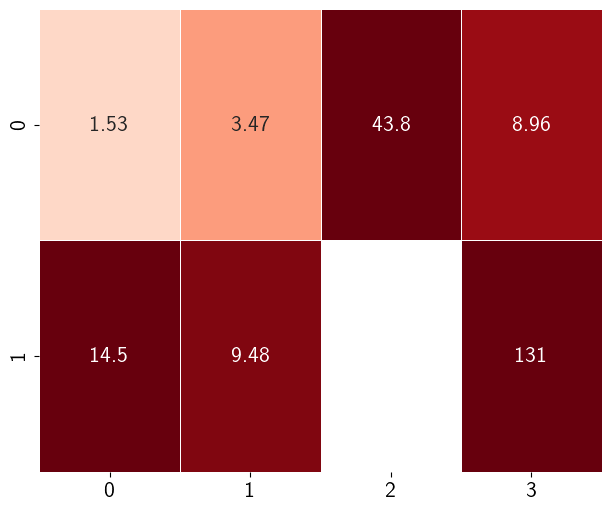

In [188]:
global_vmax = 10
utils.plot_single_heatmap(NRMSE, scenarios_train, scenarios_test, global_vmax)